# Temperature Forecasting with Simple RNN

Learn the basics of **Recurrent Neural Networks (RNNs)** by implementing a simple RNN for time-series temperature forecasting.

## What is a Simple RNN?

A **Simple RNN** (Vanilla RNN) processes sequences by maintaining a hidden state that gets updated at each timestep:

$$h_t = \tanh(W_{hh} h_{t-1} + W_{xh} x_t + b_h)$$

Where:
- $h_t$ = hidden state at time $t$
- $x_t$ = input at time $t$  
- $W_{hh}$ = weight matrix for hidden-to-hidden
- $W_{xh}$ = weight matrix for input-to-hidden
- $\tanh$ = activation function

**Simple RNN vs LSTM:**
- Simple RNN: Easier to understand, lighter computation
- LSTM: Better for long sequences, solves vanishing gradient problem

This notebook teaches you **Simple RNN first** before learning LSTM!

**Compatible**: Works in local Jupyter and Google Colab

## Section 1: Import Required Libraries

In [ ]:
# Import required libraries (PyTorch version)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

print(f"GPU Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Device: {torch.cuda.get_device_name(0)}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


GPU Available: False
Using device: cpu


## Section 2: Generate Synthetic Temperature Dataset

Create synthetic temperature data with trend and seasonal patterns

In [5]:
# Set random seed for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Generate synthetic temperature data
n_days = 500
time = np.arange(n_days)

# Components
baseline = 20  # Average temperature
trend = 0.02 * time  # Slight increase over time
seasonal = 10 * np.sin(2 * np.pi * time / 365)  # Seasonal pattern
noise = np.random.normal(0, 1, n_days)  # Random noise

# Combine
temperature = baseline + trend + seasonal + noise

# Create DataFrame
df = pd.DataFrame({
    'Day': time,
    'Temperature': temperature
})

print("TEMPERATURE DATASET")
print("=" * 60)
print(f"Total samples: {len(df)}")
print(f"\nFirst 5 rows:")
print(df.head())
print(f"\nDataset Statistics:")
print(df['Temperature'].describe())
print("=" * 60)

TEMPERATURE DATASET
Total samples: 500

First 5 rows:
   Day  Temperature
0    0    20.496714
1    1    20.053869
2    2    21.031905
3    3    22.099227
4    4    20.533871

Dataset Statistics:
count    500.000000
mean      26.945924
std        7.499854
min       12.202596
25%       20.698954
50%       27.426055
75%       32.006673
max       41.946120
Name: Temperature, dtype: float64


## Section 3: Visualize Raw Data and Rolling Mean

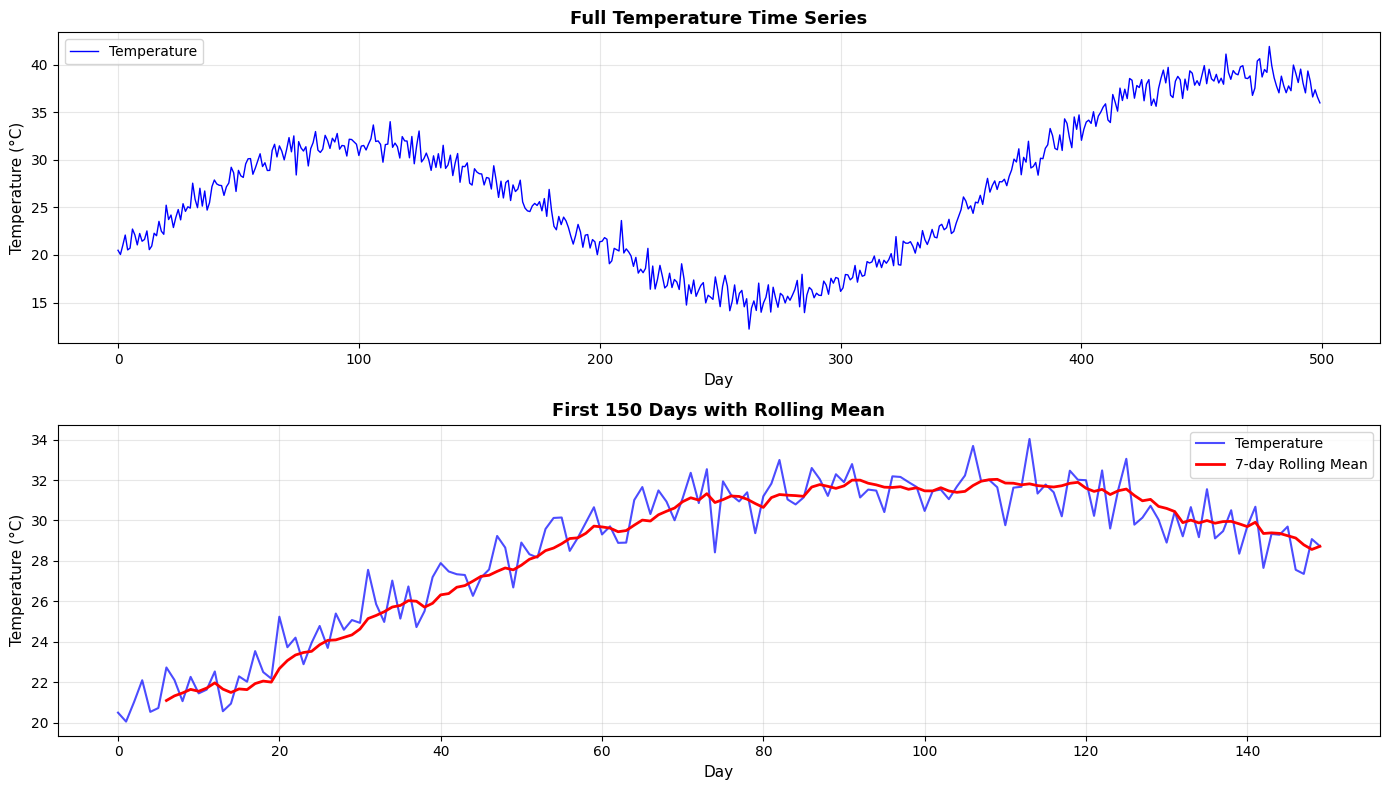

DATA VISUALIZATION
✓ Full time series plotted
✓ Rolling mean calculated (7-day window)
✓ Visible trends and seasonal patterns


In [6]:
# Visualize the temperature data
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Plot 1: Full time series
axes[0].plot(df['Day'], df['Temperature'], linewidth=1, color='blue', label='Temperature')
axes[0].set_xlabel('Day', fontsize=11)
axes[0].set_ylabel('Temperature (°C)', fontsize=11)
axes[0].set_title('Full Temperature Time Series', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Plot 2: First 150 days with rolling mean
first_n = 150
rolling_mean = df['Temperature'].iloc[:first_n].rolling(window=7).mean()
axes[1].plot(df['Day'][:first_n], df['Temperature'][:first_n], 
             linewidth=1.5, color='blue', label='Temperature', alpha=0.7)
axes[1].plot(df['Day'][:first_n], rolling_mean, 
             linewidth=2, color='red', label='7-day Rolling Mean')
axes[1].set_xlabel('Day', fontsize=11)
axes[1].set_ylabel('Temperature (°C)', fontsize=11)
axes[1].set_title(f'First {first_n} Days with Rolling Mean', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

print("=" * 60)
print("DATA VISUALIZATION")
print("=" * 60)
print(f"✓ Full time series plotted")
print(f"✓ Rolling mean calculated (7-day window)")
print(f"✓ Visible trends and seasonal patterns")
print("=" * 60)

## Section 4: Preprocess - Rescale and Create Sliding Windows

Normalize data to [0,1] range and create input sequences for RNN training

In [ ]:
# Normalize the temperature data
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(df['Temperature'].values.reshape(-1, 1)).flatten()


print(f"Original range: [{df['Temperature'].min():.2f}, {df['Temperature'].max():.2f}]")
print(f"Scaled range: [{data_scaled.min():.2f}, {data_scaled.max():.2f}]")

# Create sliding window function
def create_sequences(data, lookback=30, forecast_horizon=1):
    """
    Create sequences for RNN training
    
    Input: data = normalized time series
    lookback = number of previous timesteps to use as input
    forecast_horizon = number of future timesteps to predict (typically 1)
    
    Returns:
    X = input sequences (samples, lookback, 1)
    y = target values (samples,)
    """
    X, y = [], []
    for i in range(len(data) - lookback - forecast_horizon + 1):
        X.append(data[i:(i + lookback)])
        y.append(data[i + lookback + forecast_horizon - 1])
    return np.array(X), np.array(y)

# Parameters
lookback = 30  # Use 30 previous days to predict next day
forecast_horizon = 1

X, y = create_sequences(data_scaled, lookback=lookback, forecast_horizon=forecast_horizon)

print(f"\nSequence Creation:")
print(f"  Lookback window: {lookback} days")
print(f"  Forecast horizon: {forecast_horizon} day(s)")
print(f"  Total sequences: {len(X)}")
print(f"  X shape: {X.shape} (samples, lookback)")
print(f"  y shape: {y.shape} (samples,)")
print(f"\nExample:")
print(f"  Input sequence: {X[0]}")
print(f"  Target value: {y[0]:.4f}")
print("=" * 60)

## Section 5: Create PyTorch Dataset and DataLoader

Define custom Dataset class and split data for training

In [ ]:
# Create PyTorch Dataset class
class TemperatureDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)  # Shape: (samples, lookback)
        self.y = torch.FloatTensor(y)  # Shape: (samples,)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        # Return sequence and target
        # Expand X to add feature dimension: (lookback,) -> (lookback, 1)
        return self.X[idx].unsqueeze(1), self.y[idx]

# Split data: 70% train, 15% validation, 15% test
train_size = int(len(X) * 0.70)
val_size = int(len(X) * 0.15)

X_train = X[:train_size]
y_train = y[:train_size]

X_val = X[train_size:train_size + val_size]
y_val = y[train_size:train_size + val_size]

X_test = X[train_size + val_size:]
y_test = y[train_size + val_size:]

# Create Dataset objects
train_dataset = TemperatureDataset(X_train, y_train)
val_dataset = TemperatureDataset(X_val, y_val)
test_dataset = TemperatureDataset(X_test, y_test)

# Create DataLoaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("=" * 60)
print("DATA SPLITTING & DATALOADER")
print("=" * 60)
print(f"Total samples: {len(X)}")
print(f"Train samples: {len(X_train)} ({100*len(X_train)/len(X):.1f}%)")
print(f"Val samples:   {len(X_val)} ({100*len(X_val)/len(X):.1f}%)")
print(f"Test samples:  {len(X_test)} ({100*len(X_test)/len(X):.1f}%)")
print(f"Batch size: {batch_size}")

# Display sample batch
sample_X, sample_y = next(iter(train_loader))
print(f"\nSample batch shapes:")
print(f"  X batch: {sample_X.shape} (batch_size, lookback, features)")
print(f"  y batch: {sample_y.shape} (batch_size,)")
print(f"\nFirst sample in batch:")
print(f"  Input sequence: {sample_X[0].squeeze().numpy()}")
print(f"  Target: {sample_y[0].item():.4f}")
print("=" * 60)

## Section 6: Build SimpleRNN Model in PyTorch

Define a Simple RNN model with one RNN layer and output layer

**RNN Hidden State Update**: $$h_t = \tanh(W_{hh} h_{t-1} + W_{xh} x_t + b_h)$$

In [ ]:
# Define Simple RNN Model
class SimpleRNNModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, output_size=1, num_layers=1):
        super(SimpleRNNModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # Simple RNN layer
        # input_size: number of features in input (1 for temperature)
        # hidden_size: number of hidden units
        # num_layers: number of stacked RNN layers
        self.rnn = nn.RNN(input_size=input_size, 
                          hidden_size=hidden_size, 
                          num_layers=num_layers, 
                          batch_first=True)
        
        # Dropout for regularization
        self.dropout = nn.Dropout(p=0.2)
        
        # Fully connected output layer
        self.fc = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        # x shape: (batch_size, sequence_length, input_size)
        
        # RNN forward pass
        # rnn_out: (batch_size, sequence_length, hidden_size)
        # h_n: (num_layers, batch_size, hidden_size)
        rnn_out, h_n = self.rnn(x)
        
        # Use the output from the last timestep
        last_output = rnn_out[:, -1, :]  # (batch_size, hidden_size)
        
        # Apply dropout
        last_output = self.dropout(last_output)
        
        # Fully connected layer
        output = self.fc(last_output)  # (batch_size, 1)
        
        return output

# Model parameters
input_size = 1  # One feature (temperature)
hidden_size = 50  # Number of hidden units in RNN
num_layers = 1  # Number of RNN layers
output_size = 1  # One output (next temperature)

# Initialize model and move to device
model = SimpleRNNModel(input_size=input_size, 
                       hidden_size=hidden_size, 
                       num_layers=num_layers, 
                       output_size=output_size)
model.to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("=" * 60)
print("SIMPLE RNN MODEL")
print("=" * 60)
print(model)
print(f"\nModel Configuration:")
print(f"  Input size: {input_size}")
print(f"  Hidden size: {hidden_size}")
print(f"  Number of RNN layers: {num_layers}")
print(f"  Output size: {output_size}")
print(f"  Dropout rate: 0.2")
print(f"\nModel Parameters:")
print(f"  Total parameters: {total_params}")
print(f"  Trainable parameters: {trainable_params}")
print(f"  Device: {device}")

# Test forward pass
print(f"\nForward pass test:")
test_input = torch.randn(batch_size, lookback, input_size).to(device)
with torch.no_grad():
    test_output = model(test_input)
print(f"  Input shape: {test_input.shape}")
print(f"  Output shape: {test_output.shape}")
print("=" * 60)

## Section 7: Compile and Train Model

Train the Simple RNN model with optimization and early stopping

In [ ]:
# Loss function and optimizer
criterion = nn.MSELoss()  # Mean Squared Error for regression
optimizer = optim.Adam(model.parameters(), lr=0.001)  # Adam optimizer

# Training configuration
num_epochs = 50
patience = 10  # Early stopping patience
best_val_loss = float('inf')
patience_counter = 0

train_losses = []
val_losses = []

print("=" * 60)
print("TRAINING")
print("=" * 60)

for epoch in range(num_epochs):
    # Training phase
    model.train()
    train_loss = 0.0
    
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device).unsqueeze(-1)  # Add feature dimension
        
        # Forward pass
        y_pred = model(X_batch)
        
        # Calculate loss
        loss = criterion(y_pred, y_batch)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
    
    train_loss /= len(train_loader)
    train_losses.append(train_loss)
    
    # Validation phase
    model.eval()
    val_loss = 0.0
    
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device).unsqueeze(-1)
            
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            val_loss += loss.item()
    
    val_loss /= len(val_loader)
    val_losses.append(val_loss)
    
    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        # Save best model
        best_model_state = model.state_dict()
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\nEarly stopping at epoch {epoch+1}")
            model.load_state_dict(best_model_state)
            break
    
    # Print progress
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")

print("=" * 60)
print(f"Training completed!")
print(f"Final train loss: {train_losses[-1]:.6f}")
print(f"Final val loss: {val_losses[-1]:.6f}")
print("=" * 60)

In [ ]:
# Plot training history
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss', linewidth=2)
plt.plot(val_losses, label='Validation Loss', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (MSE)', fontsize=12)
plt.title('Training and Validation Loss', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Training history plotted!")

## Section 8: Evaluate on Test Set and Plot Predictions

Generate predictions and evaluate model performance on test data

In [ ]:
# Evaluate on test set
model.eval()
all_predictions = []
all_actuals = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        
        y_pred = model(X_batch)
        
        all_predictions.extend(y_pred.cpu().numpy().flatten())
        all_actuals.extend(y_batch.cpu().numpy().flatten())

all_predictions = np.array(all_predictions)
all_actuals = np.array(all_actuals)

# Inverse transform to original scale
all_predictions_original = scaler.inverse_transform(all_predictions.reshape(-1, 1)).flatten()
all_actuals_original = scaler.inverse_transform(all_actuals.reshape(-1, 1)).flatten()

# Calculate metrics
mse = mean_squared_error(all_actuals, all_predictions)
mae = mean_absolute_error(all_actuals, all_predictions)
rmse = np.sqrt(mse)

mse_original = mean_squared_error(all_actuals_original, all_predictions_original)
mae_original = mean_absolute_error(all_actuals_original, all_predictions_original)
rmse_original = np.sqrt(mse_original)

print("=" * 60)
print("TEST SET EVALUATION")
print("=" * 60)
print(f"Metrics (Normalized):")
print(f"  MSE: {mse:.6f}")
print(f"  MAE: {mae:.6f}")
print(f"  RMSE: {rmse:.6f}")

print(f"\nMetrics (Original Scale °C):")
print(f"  MSE: {mse_original:.4f}")
print(f"  MAE: {mae_original:.4f} °C")
print(f"  RMSE: {rmse_original:.4f} °C")

print(f"\nSample Predictions (original scale):")
for i in range(min(5, len(all_predictions_original))):
    print(f"  Sample {i+1}: Predicted {all_predictions_original[i]:.2f}°C, Actual {all_actuals_original[i]:.2f}°C")
print("=" * 60)

In [ ]:
# Plot predictions vs actual
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Plot 1: Full test set
axes[0].plot(all_actuals_original, label='Actual', linewidth=2, alpha=0.7, color='blue')
axes[0].plot(all_predictions_original, label='Predicted', linewidth=2, alpha=0.7, color='red')
axes[0].set_xlabel('Test Sample', fontsize=11)
axes[0].set_ylabel('Temperature (°C)', fontsize=11)
axes[0].set_title('Predicted vs Actual Temperature (Full Test Set)', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Plot 2: First 100 samples for detail
axes[1].plot(all_actuals_original[:100], label='Actual', linewidth=2, marker='o', 
             markersize=3, alpha=0.7, color='blue')
axes[1].plot(all_predictions_original[:100], label='Predicted', linewidth=2, marker='s', 
             markersize=3, alpha=0.7, color='red')
axes[1].set_xlabel('Test Sample', fontsize=11)
axes[1].set_ylabel('Temperature (°C)', fontsize=11)
axes[1].set_title('First 100 Predictions (Detail View)', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Section 9: Save and Export Model

Save the trained model and scaler for future inference

In [ ]:
# Save model
model_path = 'temperature_forecasting_simplernn_model.pth'
torch.save(model.state_dict(), model_path)

# Save scaler
scaler_path = 'temperature_scaler.pkl'
joblib.dump(scaler, scaler_path)

print("=" * 60)
print("MODEL SAVING")
print("=" * 60)
print(f"✓ Model saved to: {model_path}")
print(f"✓ Scaler saved to: {scaler_path}")

# Save model info
model_info = {
    'input_size': input_size,
    'hidden_size': hidden_size,
    'num_layers': num_layers,
    'output_size': output_size,
    'lookback': lookback,
    'test_mae': float(mae_original),
    'test_rmse': float(rmse_original)
}

import json
with open('model_config.json', 'w') as f:
    json.dump(model_info, f, indent=2)
print(f"✓ Model config saved to: model_config.json")

print(f"\nModel Configuration:")
print(f"  Input size: {input_size}")
print(f"  Hidden size: {hidden_size}")
print(f"  Num layers: {num_layers}")
print(f"  Lookback: {lookback}")
print(f"  Test MAE: {mae_original:.4f} °C")
print(f"  Test RMSE: {rmse_original:.4f} °C")
print("=" * 60)

## Section 10: Inference on New Sequences

Load the trained model and make predictions on new data

In [ ]:
# Function to load and make predictions
def load_and_predict(raw_sequence):
    """
    Load saved model and make predictions on new data
    
    Args:
        raw_sequence: numpy array of recent temperatures (raw scale)
    
    Returns:
        next_temp: predicted next temperature (original scale)
    """
    # Load model and scaler
    loaded_model = SimpleRNNModel(input_size=input_size, 
                                  hidden_size=hidden_size, 
                                  num_layers=num_layers)
    loaded_model.load_state_dict(torch.load(model_path))
    loaded_model.to(device)
    loaded_model.eval()
    
    loaded_scaler = joblib.load(scaler_path)
    
    # Normalize input
    raw_sequence = np.array(raw_sequence).reshape(-1, 1)
    scaled_sequence = loaded_scaler.transform(raw_sequence).flatten()
    
    # Take last 'lookback' values
    if len(scaled_sequence) >= lookback:
        input_seq = scaled_sequence[-lookback:]
    else:
        # Pad with first values if shorter than lookback
        input_seq = np.concatenate([scaled_sequence[0:1] * (lookback - len(scaled_sequence)), 
                                     scaled_sequence])
    
    # Prepare tensor
    input_tensor = torch.FloatTensor(input_seq).unsqueeze(0).unsqueeze(-1).to(device)
    # Shape: (1, lookback, 1)
    
    # Make prediction
    with torch.no_grad():
        pred_normalized = loaded_model(input_tensor).cpu().numpy()[0, 0]
    
    # Inverse transform
    pred_original = loaded_scaler.inverse_transform([[pred_normalized]])[0, 0]
    
    return pred_original

# Test inference with last sequence from data
print("=" * 60)
print("INFERENCE TEST")
print("=" * 60)

# Use last temperatures from original data
test_recent_temps = df['Temperature'].iloc[-lookback:].values

print(f"Recent temperatures (last {lookback} days):")
print(f"  {test_recent_temps}")

# Make prediction
predicted_temp = load_and_predict(test_recent_temps)

print(f"\nPrediction:")
print(f"  Predicted next temperature: {predicted_temp:.2f}°C")
print(f"  Last actual temperature: {test_recent_temps[-1]:.2f}°C")
print(f"  Difference: {abs(predicted_temp - test_recent_temps[-1]):.2f}°C")

print("\n" + "=" * 60)
print("NOTEBOOK COMPLETE!")
print("=" * 60)
print("\nYou have successfully trained a Simple RNN for temperature forecasting!")
print("\nKey Learning Points:")
print("  ✓ RNN basics and hidden state mechanism")
print("  ✓ Time-series preprocessing and sliding windows")
print("  ✓ PyTorch model architecture (nn.RNN layer)")
print("  ✓ Training loop with early stopping")
print("  ✓ Model evaluation and visualization")
print("  ✓ Save/load model and scaler")
print("  ✓ Making predictions on new data")
print("\nNext step: Learn about LSTM improvements over Simple RNN!")
print("=" * 60)